<a href="https://colab.research.google.com/github/NBK-code/Reinforcement_Learning/blob/main/Model_Free_RL_with_Monte_Carlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Model-Free Reinforcement Learning

$P(r, s' | s, a)$ is not known. So the only way to know about the environment is to interact with the environment. We will get many trajectories of the agent by interacting with the environment and then use them to directly infer the Q-values using Monte-Carlo method.

In [1]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

In [2]:
env = gym.make("FrozenLake-v1", is_slippery=True)

In [37]:
def sample_trajectory(policy, env, max_steps=50, epsilon=0.1):

  done = False
  trajectory = []
  num_steps = 0

  state, _ = env.reset()

  while not done:

    if np.random.rand() < epsilon:
      action = env.action_space.sample()
    else:
      action = policy[state]

    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

    experience = (state, int(action), reward, next_state, done)
    trajectory.append(experience)

    num_steps += 1

    if num_steps >= max_steps:
      done = True
      break

    state = next_state

  return trajectory

In [38]:
policy = np.random.choice(env.action_space.n, size = (env.observation_space.n, ))
print(policy)

[3 2 2 1 2 3 3 2 3 0 2 0 2 2 3 1]


In [39]:
trajectory = sample_trajectory(policy, env)

In [41]:
print(trajectory)

[(0, 3, 0, 1, False), (1, 2, 0, 2, False), (2, 2, 0, 3, False), (3, 1, 0, 3, False), (3, 1, 0, 2, False), (2, 2, 0, 6, False), (6, 3, 0, 7, True)]


In [42]:
def compute_returns(trajectory, gamma = 0.99):
  returns = {}
  G = 0

  for t in reversed(trajectory):
    state, action, reward, _, _ = t
    G = reward + gamma * G

    if (state, action) not in returns:
      returns[(state, action)] = G

  return returns

In [43]:
print(compute_returns(trajectory))

{(6, 3): 0.0, (2, 2): 0.0, (3, 1): 0.0, (1, 2): 0.0, (0, 3): 0.0}


In [44]:
def monte_carlo_estimation(policy, env, gamma=0.99, max_steps=50, num_episodes=5000):

  Q = np.zeros((env.observation_space.n, env.action_space.n))
  returns = {(s, a): [] for s in range(env.observation_space.n) for a in range(env.action_space.n)}

  for _ in range(num_episodes):

    trajectory = sample_trajectory(policy, env, max_steps)
    returns_for_episode = compute_returns(trajectory, gamma)

    for (state,action), G in returns_for_episode.items():
      returns[(state,action)].append(G)

  for (state, action), returns_list in returns.items():
    if len(returns_list) > 0:
      Q[state, action] = np.mean(returns_list)

  return Q

In [45]:
monte_carlo_estimation(policy, env)

array([[2.43768753e-03, 7.12355244e-03, 2.51061373e-03, 2.12510483e-03],
       [0.00000000e+00, 0.00000000e+00, 1.62887930e-03, 9.75598638e-03],
       [7.58046094e-03, 0.00000000e+00, 3.34687370e-03, 0.00000000e+00],
       [0.00000000e+00, 7.29381936e-04, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 5.15441761e-03, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [5.15842105e-02, 3.98040612e-02, 9.37727335e-02, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.81244530e-02],
       [3.13406418e-02, 2.42574750e-01, 0.00000000e+00, 0.00000000e+00],
       [3.17252875e-01, 0.00000000e+00, 1.09842857e-01, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 1.13850000e

In [46]:
def policy_improvement(Q):
    return np.argmax(Q, axis=-1)

In [47]:
def monte_carlo_policy_iteration(env, gamma=0.99, max_steps=50, num_episodes=10000):

    policy = np.random.choice(env.action_space.n, size=(env.observation_space.n, ))

    while True:
        Q = monte_carlo_estimation(policy, env, gamma, max_steps, num_episodes)
        new_policy = policy_improvement(Q)

        if np.array_equal(policy, new_policy):
            break

        policy = new_policy

    return policy, Q

In [48]:
optimal_policy, optimal_Q = monte_carlo_policy_iteration(env)

print(optimal_policy)

[0 3 0 1 0 0 2 0 3 1 0 0 0 2 1 0]


In [49]:
def test_policy(policy, env, num_episodes=500):
    success_count = 0

    for _ in range(num_episodes):
        state, _ = env.reset()
        done = False

        while not done:
            action = policy[state]
            state, reward, done, _, _ = env.step(action)

            if done and reward == 1.0:  # Reached the goal
                success_count += 1

    success_rate = success_count / num_episodes
    print(f"Policy Success Rate: {success_rate * 100:.2f}%")

# Test the learned policy
test_policy(optimal_policy, env)

Policy Success Rate: 77.80%


###Online Monte-Carlo

$Q_{k+1} = Q_k + \frac{1}{k+1}(G_{k+1}-Q_k)$

In [52]:
def online_monte_carlo_estimation(policy, env, gamma=0.99, max_steps=50, num_episodes=5000):

    Q = np.zeros((env.observation_space.n, env.action_space.n))

    N = np.zeros((env.observation_space.n, env.action_space.n))

    for _ in range(num_episodes):
        trajectory = sample_trajectory(policy, env, max_steps)
        returns = compute_returns(trajectory, gamma)

        for (state, action), G in returns.items():
            Q[state, action] = Q[state, action] + (G - Q[state, action]) / (N[state, action] + 1)
            N[state, action] += 1

    return Q

In [54]:
def online_monte_carlo_policy_iteration(env, gamma=0.99, max_steps=50, num_episodes=10000):

    policy = np.random.choice(env.action_space.n, size=(env.observation_space.n, ))

    while True:
        Q = online_monte_carlo_estimation(policy, env, gamma, max_steps, num_episodes)
        new_policy = policy_improvement(Q)

        if np.array_equal(policy, new_policy):
            break

        policy = new_policy

    return policy, Q

In [55]:
optimal_policy, optimal_Q = online_monte_carlo_policy_iteration(env)

print(optimal_policy)

[0 3 3 3 0 0 0 0 3 1 0 0 0 2 1 0]


In [56]:
test_policy(optimal_policy, env)

Policy Success Rate: 83.00%


###Online Monte-Carlo with Learning Rate

$Q_{k+1} = Q_k + \alpha_t(G_{k+1}-Q_k)$

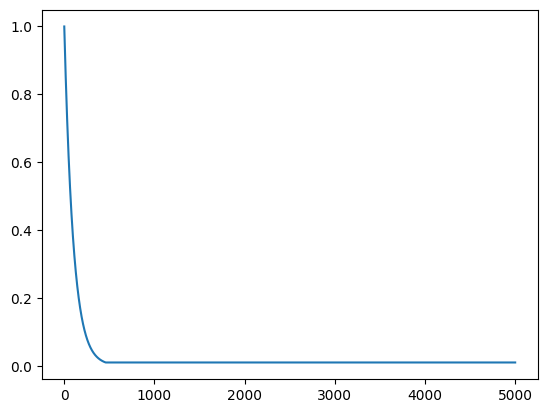

In [57]:
def lr_scheduler(start_val, min_val, decay_factor, num_episodes):

    alphas = [start_val * decay_factor**episode for episode in range(num_episodes)]
    alphas = [a if a >= min_val else min_val for a in alphas]

    return alphas

alphas = lr_scheduler(1.0, 0.01, 0.99, 5000)

plt.plot(alphas)
plt.show()

In [58]:
def online_monte_carlo_estimation_w_lr(policy, env, gamma=0.99, max_steps=50, num_episodes=5000,
                                       lr_start_val=0.8, lr_min_val=0.01, lr_decay_factor=0.99):

    Q = np.zeros((env.observation_space.n, env.action_space.n))

    alphas = lr_scheduler(lr_start_val, lr_min_val, lr_decay_factor, num_episodes)

    for i in range(num_episodes):
        trajectory = sample_trajectory(policy, env, max_steps)
        returns = compute_returns(trajectory, gamma)

        for (state, action), G in returns.items():
            Q[state, action] = Q[state, action] + alphas[i] * (G - Q[state, action])

    return Q

In [59]:
def online_monte_carlo_w_lr_policy_iteration(env,
                                 gamma=0.99,
                                 max_steps=50,
                                 num_episodes=10000,
                                 lr_start_val=0.6,
                                 lr_min_val=0.01,
                                 lr_decay_factor=0.98):


    policy = np.random.choice(env.action_space.n, size=(env.observation_space.n, ))

    while True:
        Q = online_monte_carlo_estimation_w_lr(policy, env, gamma, max_steps, num_episodes, lr_start_val, lr_min_val, lr_decay_factor)
        new_policy = policy_improvement(Q)

        if np.array_equal(policy, new_policy):
            break

        policy = new_policy

    return policy, Q

In [66]:
optimal_policy, optimal_Q = online_monte_carlo_w_lr_policy_iteration(env)

print(optimal_policy)

[0 1 1 0 0 0 2 0 3 1 1 0 0 2 1 0]


In [67]:
test_policy(optimal_policy, env)

Policy Success Rate: 60.20%
